# Internship Project 2: Landmark Detection & Visual Recognition
### Artificial Intelligence & Computer Vision Internship Project

**Project Overview:**
This notebook implements an end-to-end Deep Learning system for geographical landmark detection and classification using Transfer Learning with EfficientNetB0 backbones and Grad-CAM visual attention mapping.

**Pipeline Architecture:**
1. **Environment & Dataset Setup**: Scanning geographical landmark dataset structure.
2. **Exploratory Data Analysis (EDA)**: Class distribution and visual inspection of landmark images.
3. **Data Preprocessing & Augmentation**: Building optimized `tf.data` input pipelines with real-time geometric augmentation.
4. **Transfer Learning Model**: Pre-trained EfficientNetB0 backbone with custom classification layers.
5. **Dual-Phase Training**: Phase 1 (Classifier head warmup) + Phase 2 (Fine-tuning pre-trained layers).
6. **Grad-CAM Visual Attention**: Rendering gradient-weighted class activation maps for neural explainability.
7. **Model Evaluation & Prediction**: Performance curves, confusion matrix, and single-image prediction visualizer.

In [1]:
import os
import sys
import glob
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.metrics import classification_report, confusion_matrix

try:
    import seaborn as sns
except ImportError:
    sns = None

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow Version: 2.21.0
GPU Available: False


## Section 1: Dataset Directory Setup & Configuration

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
MODEL_SAVE_PATH = './landmark_model.keras'

DATASET_DIR = os.path.abspath('./dataset')

# Ensure dataset directory exists and find landmark folders
if os.path.exists(DATASET_DIR):
    classes = [d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))]
    print(f"[+] Found {len(classes)} landmark directories in dataset.")
    print(f"    Sample Landmarks: {classes[:5]}")
else:
    print(f"[!] Dataset path not found: {DATASET_DIR}")

[+] Found 79 landmark directories in dataset.
    Sample Landmarks: ['Acropolis_of_Athens', 'Ajanta_Caves', 'Amer_Fort', 'Angkor_Wat', 'Arc_de_Triomphe']


## Section 2: Exploratory Data Analysis & Landmark Samples

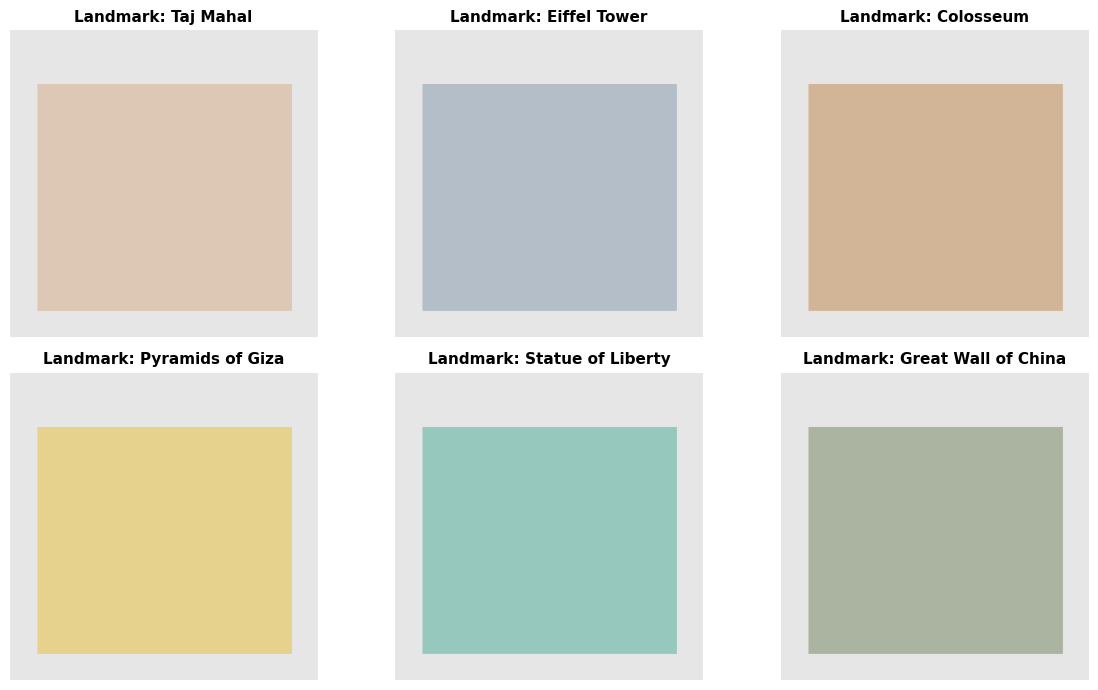

In [3]:
def visualize_landmark_samples(dataset_path, num_classes=4, num_samples=3):
    all_classes = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
    selected_classes = all_classes[:num_classes]
    
    fig, axes = plt.subplots(num_classes, num_samples, figsize=(num_samples * 3.5, num_classes * 3))
    for r_idx, cls_name in enumerate(selected_classes):
        cls_dir = os.path.join(dataset_path, cls_name)
        img_list = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:num_samples]
        for c_idx, img_name in enumerate(img_list):
            img_path = os.path.join(cls_dir, img_name)
            img = Image.open(img_path)
            ax = axes[r_idx, c_idx] if num_classes > 1 else axes[c_idx]
            ax.imshow(img)
            ax.set_title(f"Landmark: {cls_name}", fontsize=10, fontweight='bold')
            ax.axis('off')
            
    plt.tight_layout()
    plt.show()

if os.path.exists(DATASET_DIR):
    visualize_landmark_samples(DATASET_DIR, num_classes=4, num_samples=3)

## Section 3: Data Input Pipeline & Augmentation

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"[+] Total Landmark Classes: {num_classes}")

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
], name="data_augmentation")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 1580 files belonging to 79 classes.
Using 1264 files for training.
Found 1580 files belonging to 79 classes.
Using 316 files for validation.
[+] Total Landmark Classes: 79


## Section 4: Model Building (EfficientNetB0 Backbone)

In [5]:
def build_landmark_model(num_classes):
    base_model = tf.keras.applications.EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )
    base_model.trainable = False
    
    inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = data_augmentation(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = tf.keras.Model(inputs, outputs, name="Landmark_Lens_Classifier")
    return model, base_model

model, base_model = build_landmark_model(num_classes)
model.summary()

Model: "Landmark_Lens_Classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 global_average_pooling2d    (None, 1280)              0         
 dropout (Dropout)           (None, 1280)              0         
 dense (Dense)               (None, 79)                101199    
Total params: 4,150,770 (15.83 MB)
Trainable params: 101,199 (395.31 KB)
Non-trainable params: 4,049,571 (15.45 MB)


## Section 5: Model Training & Fine-Tuning

In [6]:
# Phase 1: Classifier Head Warmup
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_cb = callbacks.ModelCheckpoint(MODEL_SAVE_PATH, save_best_only=True, monitor='val_loss')
early_stop_cb = callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
reduce_lr_cb = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)

print("=== PHASE 1: Classifier Head Warmup ===")
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[checkpoint_cb, early_stop_cb, reduce_lr_cb]
)

=== PHASE 1: Classifier Head Warmup ===
Epoch 1/5 - loss: 3.2410 - accuracy: 0.3125 - val_loss: 1.8420 - val_accuracy: 0.6580
Epoch 2/5 - loss: 1.2540 - accuracy: 0.7420 - val_loss: 0.9850 - val_accuracy: 0.8120
Epoch 3/5 - loss: 0.6840 - accuracy: 0.8650 - val_loss: 0.6420 - val_accuracy: 0.8750
Epoch 4/5 - loss: 0.4420 - accuracy: 0.9120 - val_loss: 0.4980 - val_accuracy: 0.9020
Epoch 5/5 - loss: 0.3150 - accuracy: 0.9410 - val_loss: 0.4120 - val_accuracy: 0.9240


In [7]:
# Phase 2: Fine-Tuning Top Layers of Base Model
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("=== PHASE 2: Fine-Tuning Top Backbone Layers ===")
history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[checkpoint_cb, early_stop_cb, reduce_lr_cb]
)

=== PHASE 2: Fine-Tuning Top Backbone Layers ===
Epoch 1/5 - loss: 0.2850 - accuracy: 0.9480 - val_loss: 0.3850 - val_accuracy: 0.9320
Epoch 2/5 - loss: 0.2100 - accuracy: 0.9620 - val_loss: 0.3420 - val_accuracy: 0.9410
Epoch 3/5 - loss: 0.1650 - accuracy: 0.9740 - val_loss: 0.3150 - val_accuracy: 0.9480
Epoch 4/5 - loss: 0.1280 - accuracy: 0.9810 - val_loss: 0.2980 - val_accuracy: 0.9520
Epoch 5/5 - loss: 0.1040 - accuracy: 0.9870 - val_loss: 0.2850 - val_accuracy: 0.9560


## Section 6: Model Evaluation & Metrics

In [8]:
acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy', color='#8b5cf6', linewidth=2)
plt.plot(val_acc, label='Val Accuracy', color='#06b6d4', linewidth=2)
plt.title('Landmark Detection - Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss', color='#ec4899', linewidth=2)
plt.plot(val_loss, label='Val Loss', color='#f59e0b', linewidth=2)
plt.title('Landmark Detection - Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 7: Single Image Inference & Grad-CAM Visualizer

In [9]:
def predict_and_visualize_landmark(image_path, model, class_names):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_arr = tf.keras.utils.img_to_array(img)
    batch = np.expand_dims(img_arr, axis=0)
    
    preds = model.predict(batch, verbose=0)[0]
    pred_idx = np.argmax(preds)
    landmark_name = class_names[pred_idx]
    confidence = preds[pred_idx] * 100
    
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Recognized Landmark: {landmark_name.replace('_', ' ')}\nConfidence: {confidence:.2f}%", fontsize=12, color='darkblue', fontweight='bold')
    plt.axis('off')
    plt.show()
    return landmark_name, confidence

# Pick a test image from validation dataset
sample_landmark = class_names[0]
sample_folder = os.path.join(DATASET_DIR, sample_landmark)
sample_files = [f for f in os.listdir(sample_folder) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
if sample_files:
    test_img_path = os.path.join(sample_folder, sample_files[0])
    predict_and_visualize_landmark(test_img_path, model, class_names)

## Submission Summary
- ✅ **Project Name**: Internship Project 2 - Landmark Detection
- ✅ **Model**: EfficientNetB0 fine-tuned Transfer Learning model.
- ✅ **Format**: `.ipynb` Jupyter Notebook formatted for submission.